# Hugging Face Models

This notebook walks through the Deckard Python API from a transformers-centric perspective and mirrors the core feature coverage used in the sklearn and pytorch notebooks.

It is aligned to the flattened attack runtime contract: [AttackConfig](../api/attack/index) is the orchestration entrypoint, and canonical attack names dispatch to built-in ART handlers or dedicated plugin runtime configs ([TextAttackConfig](../api/plugins/textattack), [OpenAttackConfig](../api/plugins/openattack)).

## Navigation

1. Dependency notes and environment
2. Core dataset API
3. Core model API
4. Adversarial attack API (built-in ART path)
5. Plugin attack runtime resolution (TextAttack/OpenAttack)
6. End-to-end experiment composition
7. Fairness extension (AttackScorerConfig-based)
8. Model checkpointing
9. Yellowbrick plotter
10. Seaborn plotter
11. Final summary dataframe

The final summary dataframe cell is intentionally stable so docs automation can rely on a consistent terminal output section.

In [1]:
# Notebook dependencies
REQUIRED_DEPENDENCIES = [
    "transformers",
    "datasets",
    "hydra-core",
    "adversarial-robustness-toolbox",
    "textattack",
    "OpenAttack",
]

print("Required dependencies:")
for dep in REQUIRED_DEPENDENCIES:
    print(f"- {dep}")

# Optional one-shot install command (kept commented by default).
# !pip install -e ".[transformers,textattack,openattack]"

Required dependencies:
- transformers
- datasets
- hydra-core
- adversarial-robustness-toolbox
- textattack
- OpenAttack


## 1. Environment and Imports

This notebook runs Deckard with tuned Hugging Face model and dataset defaults from `examples/transformers/config/default.yaml` (currently SST-2 with a fine-tuned DistilBERT checkpoint).

Attack runtime notes for this notebook:

- Built-in ART attack names route through core attack family handlers.
- `textattack.attack_recipes.*` routes to [TextAttackConfig](../api/plugins/textattack).
- `OpenAttack.attackers.*` routes to [OpenAttackConfig](../api/plugins/openattack).

Reference notebook: [ART Hugging Face notebook](https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/huggingface_notebook.ipynb)

## 2. Core Dataset API

Compose the transformers default config with Hydra, normalize the notebook-local dataset path, and materialize the dataset through DataConfig.

In [2]:
from pathlib import Path

from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if not (repo_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate repo root containing pyproject.toml.")
config_dir = repo_root / "examples" / "transformers" / "config"
dataset_file = (repo_root / "examples" / "transformers" / "hf_task_datasets.py").resolve()

with initialize_config_dir(version_base=None, config_dir=str(config_dir)):
    cfg = compose(config_name="default")

# Normalize dataset class path for notebook execution cwd.
cfg.data.dataset = f"{dataset_file}:ArithmeticMathQADataset"

# Keep docs notebook execution bounded by capping the example sampler sizes.
sampler_cfg_raw = OmegaConf.to_container(cfg.data.sampler, resolve=True)
if not isinstance(sampler_cfg_raw, dict):
    raise TypeError(f"Expected cfg.data.sampler to resolve to dict, got {type(sampler_cfg_raw)}")

sampler_cfg = dict(sampler_cfg_raw)
NOTEBOOK_TRAIN_LIMIT = 128
NOTEBOOK_TEST_LIMIT = 64
sampler_cfg["train_size"] = min(int(sampler_cfg.get("train_size", NOTEBOOK_TRAIN_LIMIT)), NOTEBOOK_TRAIN_LIMIT)
sampler_cfg["test_size"] = min(int(sampler_cfg.get("test_size", NOTEBOOK_TEST_LIMIT)), NOTEBOOK_TEST_LIMIT)
cfg.data.sampler = sampler_cfg

files_cfg = instantiate(cfg.files)
data_cfg = instantiate(cfg.data)

_ = data_cfg(files=files_cfg.as_dict())
base_dataset = data_cfg._X[1].dataset if hasattr(data_cfg._X[1], "dataset") else data_cfg._X[1]

{
    "experiment_name": cfg.experiment_name,
    "data_alias": cfg.data.alias,
    "sampler": cfg.data.sampler,
    "dataset_type": type(base_dataset).__name__,
    "sample_text": base_dataset.texts[0] if hasattr(base_dataset, "texts") and base_dataset.texts else None,
}

/Users/c.meyers/Documents/deckard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Materializing train batches:   0%|                      | 0/256 [00:00<?, ?it/s]

Materializing train batches:  24%|██▊         | 61/256 [00:00<00:00, 607.15it/s]

Materializing train batches:  48%|█████▏     | 122/256 [00:00<00:00, 596.88it/s]

Materializing train batches:  71%|███████▊   | 183/256 [00:00<00:00, 600.69it/s]

Materializing train batches:  96%|██████████▌| 246/256 [00:00<00:00, 610.44it/s]

Materializing test batches:   0%|                       | 0/114 [00:00<?, ?it/s]

Materializing test batches:  47%|██████▏      | 54/114 [00:00<00:00, 537.37it/s]

Materializing test batches:  95%|███████████▎| 108/114 [00:00<00:00, 533.99it/s]

{'experiment_name': 'transformers_hsj_sst2_tuned',
 'data_alias': 'sst2_sentiment',
 'sampler': {'name': 'deckard.frameworks.pytorch.sample.PytorchSplitSampler', 'train_size': 128, 'test_size': 64, 'random_state': 42, 'stratify': True},
 'dataset_type': 'ArithmeticMathQADataset',
 'sample_text': 'uneasy mishmash of styles and genres .'}

## 3. Core Model API

Instantiate model and attack configs from the composed transformers defaults.

The attack object remains a canonical [AttackConfig](../api/attack/index) that resolves a concrete runtime handler at execution time based on `name` (built-in ART family names or plugin-native namespaces).

In [3]:
# Instantiate model + attack from the tuned default config pair.
import importlib
from hydra.utils import instantiate

import deckard.frameworks.transformers.declarations as hf_decl_module
import deckard.frameworks.transformers.model as hf_model_module
importlib.reload(hf_decl_module)
importlib.reload(hf_model_module)

model_cfg = instantiate(cfg.model)
attack_cfg = instantiate(cfg.attack)

{
    "model_target": cfg.model.name,
    "model_alias": cfg.model.alias,
    "attack_name": cfg.attack.name,
    "attack_alias": cfg.attack.alias,
    "data_alias": cfg.data.alias,
}

{'model_target': 'deckard.frameworks.transformers.declarations.PretrainedSequenceClassificationTransformer',
 'model_alias': 'hf_distilbert_sst2_tuned',
 'attack_name': 'art.attacks.evasion.HopSkipJump',
 'attack_alias': 'hsj',
 'data_alias': 'sst2_sentiment'}

## 4. Adversarial Attack API (Built-in ART Path)

Run the configured built-in attack over the loaded dataset and model. This follows the flattened runtime model where [AttackConfig](../api/attack/index) remains the orchestration owner and dispatches to the appropriate family handler.

In [4]:
import importlib.util

# Full Deckard-native run: data -> model -> HSJ attack.
if importlib.util.find_spec("transformers") is None:
    raise ImportError(
        "This notebook requires the optional dependency group for transformers. "
        "Install with: pip install -e '.[transformers]'"
    )

model_cfg = instantiate(cfg.model)
_ = data_cfg(files=files_cfg.as_dict())
_ = model_cfg(data_cfg, files=files_cfg.as_dict())
attack_scores = attack_cfg(data=data_cfg, model=model_cfg, files=files_cfg.as_dict())

{
    "attack_name": cfg.attack.name,
    "attack_alias": cfg.attack.alias,
    "score_keys": sorted(list(attack_scores.keys()))[:10],
    "metric_preview": {
        "benign_accuracy": attack_scores.get("benign_accuracy"),
        "evasion_success": attack_scores.get("evasion_success"),
    },
}

{'attack_name': 'art.attacks.evasion.HopSkipJump',
 'attack_alias': 'hsj',
 'score_keys': ['attack_execution_order',
  'attack_generation_time',
  'attack_prediction_time',
  'attack_score_time',
  'attack_size',
  'attack_stage',
  'benign_accuracy',
  'benign_attack_score_time',
  'benign_attack_size',
  'benign_f1'],
 'metric_preview': {'benign_accuracy': 0.0, 'evasion_success': 0.6}}

## 5. Plugin Attack Runtime Resolution (TextAttack and OpenAttack)

The flattened attack model keeps plugin boundaries explicit while preserving canonical third-party names. This cell inspects runtime-family parsing and handler type resolution for TextAttack and OpenAttack attack names.

In [5]:
from deckard.attack.base import AttackConfig, _resolve_plugin_runtime_config_type

plugin_attack_names = [
    "textattack.attack_recipes.deepwordbug_gao_2018.DeepWordBugGao2018",
    "OpenAttack.attackers.PWWSAttacker",
]

plugin_runtime_preview = {}
for attack_name in plugin_attack_names:
    configured = AttackConfig(name=attack_name, attack_size=16, alias="plugin_probe")
    runtime_cls = _resolve_plugin_runtime_config_type(attack_name)
    runtime_config = runtime_cls(name=attack_name, attack_size=16) if runtime_cls else None

    library, _, tail = attack_name.partition(".")
    plugin_runtime_preview[attack_name] = {
        "configured_name": configured.name,
        "attack_config_type": type(configured).__name__,
        "runtime_config_type": type(runtime_config).__name__ if runtime_config is not None else None,
        "library": library,
        "attack_path_tail": tail,
    }

plugin_runtime_preview

{'textattack.attack_recipes.deepwordbug_gao_2018.DeepWordBugGao2018': {'configured_name': 'textattack.attack_recipes.deepwordbug_gao_2018.DeepWordBugGao2018',
  'attack_config_type': 'AttackConfig',
  'runtime_config_type': 'TextAttackConfig',
  'library': 'textattack',
  'attack_path_tail': 'attack_recipes.deepwordbug_gao_2018.DeepWordBugGao2018'},
 'OpenAttack.attackers.PWWSAttacker': {'configured_name': 'OpenAttack.attackers.PWWSAttacker',
  'attack_config_type': 'AttackConfig',
  'runtime_config_type': 'OpenAttackConfig',
  'library': 'OpenAttack',
  'attack_path_tail': 'attackers.PWWSAttacker'}}

## 6. End-to-End Experiment Composition

This cell executes the data -> model -> attack flow in one sequence, mirroring the same high-level composition pattern used in sklearn and pytorch notebooks.

In [6]:
# Section 6 code example: instantiate and run the canonical ExperimentConfig.
from deckard.experiment import ExperimentConfig

experiment_cfg = ExperimentConfig(
    experiment_name=cfg.experiment_name,
    data=data_cfg,
    model=model_cfg,
    attack=attack_cfg,
    files=files_cfg,
    library="pytorch",
    score_mode="test",
)

experiment_scores = experiment_cfg()

composition_preview = {
    "experiment_name": experiment_cfg.experiment_name,
    "experiment_config_type": type(experiment_cfg).__name__,
    "data_class": type(experiment_cfg.data).__name__,
    "model_class": type(experiment_cfg.model).__name__ if experiment_cfg.model is not None else None,
    "attack_class": type(experiment_cfg.attack).__name__ if experiment_cfg.attack is not None else None,
    "score_keys": sorted(list(experiment_scores.keys()))[:10],
}

composition_preview

{'experiment_name': 'transformers_hsj_sst2_tuned',
 'experiment_config_type': 'ExperimentConfig',
 'data_class': 'PytorchCustomDataConfig',
 'model_class': 'HuggingFacePytorchModelConfig',
 'attack_class': 'AttackConfig',
 'score_keys': ['accuracy',
  'attack_execution_order',
  'attack_generation_time',
  'attack_prediction_time',
  'attack_score_time',
  'attack_size',
  'attack_stage',
  'benign_accuracy',
  'benign_attack_score_time',
  'benign_attack_size']}

## 7. Fairness Extension (TinyFairness Group Accuracy Only)

This section uses the synthetic TinyFairness dataset to demonstrate group-scoring behavior without adversarial attack simulation.

It computes classification accuracy by sensitive group (`A` vs `B`) and reports both group-level and overall accuracy.

In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from deckard.frameworks.pytorch.fairness_data import TinyFairness

# Tiny synthetic fairness dataset with built-in sensitive groups.
tiny_fairness = TinyFairness(num_samples=80, n_features=6, random_state=7)
X = np.asarray(tiny_fairness._X, dtype=float)
y_true = np.asarray(tiny_fairness._y, dtype=int)
sensitive = [str(group) for group in tiny_fairness._sensitive]

# Fit a simple deterministic classifier (no attack simulation, no label flipping).
classifier = LogisticRegression(max_iter=400, random_state=7)
classifier.fit(X, y_true)
y_pred = classifier.predict(X)

eval_df = pd.DataFrame(
    {
        "group": sensitive,
        "y_true": y_true,
        "y_pred": y_pred,
    }
)
eval_df["is_correct"] = eval_df["y_true"] == eval_df["y_pred"]

group_accuracy_df = (
    eval_df.groupby("group", as_index=False)
    .agg(
        samples=("is_correct", "size"),
        accuracy=("is_correct", "mean"),
    )
    .sort_values("group")
    .reset_index(drop=True)
)
group_accuracy_df["accuracy"] = group_accuracy_df["accuracy"].astype(float)

overall_accuracy = float(accuracy_score(y_true, y_pred))
summary_table = pd.concat(
    [
        group_accuracy_df,
        pd.DataFrame(
            [{"group": "overall", "samples": int(len(eval_df)), "accuracy": overall_accuracy}]
        ),
    ],
    ignore_index=True,
)

{
    "dataset": "TinyFairness",
    "n_samples": int(y_true.shape[0]),
    "group_counts": {group: sensitive.count(group) for group in sorted(set(sensitive))},
    "per_group_accuracy": summary_table,
}

{'dataset': 'TinyFairness',
 'n_samples': 80,
 'group_counts': {'A': 37, 'B': 43},
 'per_group_accuracy':      group  samples  accuracy
 0        A       37  0.621622
 1        B       43  0.674419
 2  overall       80  0.650000}

## 8. Model Checkpointing

This section writes concrete model/checkpoint artifacts when supported by the active model config and records what was produced.

If the model class does not expose a checkpoint API, the cell still produces a checkpoint manifest with artifact existence signals.

In [8]:
import pandas as pd
from pathlib import Path

artifact_dir = Path.cwd().resolve() / "build" / "huggingface"
artifact_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir = artifact_dir / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_model_file = checkpoint_dir / "hf_model.yaml"
checkpoint_state_file = checkpoint_dir / "hf_model_state.pt"

save_config_ok = False
save_state_ok = False
save_errors = []

if hasattr(model_cfg, "save"):
    try:
        model_cfg.save(checkpoint_model_file.as_posix())
        save_config_ok = checkpoint_model_file.exists()
    except Exception as exc:
        save_errors.append(f"save(path) failed: {exc}")
        try:
            model_cfg.save()
            save_config_ok = checkpoint_model_file.exists()
        except Exception as exc2:
            save_errors.append(f"save() failed: {exc2}")

if hasattr(model_cfg, "save_model"):
    try:
        model_cfg.save_model(checkpoint_state_file.as_posix())
        save_state_ok = checkpoint_state_file.exists()
    except Exception as exc:
        save_errors.append(f"save_model(path) failed: {exc}")
        try:
            model_cfg.save_model()
            save_state_ok = checkpoint_state_file.exists()
        except Exception as exc2:
            save_errors.append(f"save_model() failed: {exc2}")

checkpoint_manifest = {
    "model_file": checkpoint_model_file.as_posix(),
    "model_file_exists": save_config_ok,
    "model_state_file": checkpoint_state_file.as_posix(),
    "model_state_file_exists": save_state_ok,
    "model_supports_save": hasattr(model_cfg, "save"),
    "model_supports_save_model": hasattr(model_cfg, "save_model"),
    "errors": save_errors,
}

checkpoint_df = pd.DataFrame([checkpoint_manifest])
checkpoint_df

,model_file,model_file_exists,model_state_file,model_state_file_exists,model_supports_save,model_supports_save_model,errors
0,/Users/c.meyers/Documents/deckard/docs/noteboo...,False,/Users/c.meyers/Documents/deckard/docs/noteboo...,True,True,True,[save(path) failed: Unsupported file type .yam...


## 9. Yellowbrick Plotter

This section runs Yellowbrick using Deckard config objects in the transformers workflow.

To keep the run stable and relevant to classification tasks, it executes only classifier visualizers (`roc_auc`, `precision_recall_curve`, `classification_report`, `class_prediction_error`, `discrimination_threshold`).

{'yellowbrick_env': {'yellowbrick_installed': True,
  'plot_mode': 'classifier_only',
  'available_plot_types': ['roc_auc',
   'precision_recall_curve',
   'classification_report',
   'class_prediction_error',
   'discrimination_threshold'],
  'primary_plot_file': '/Users/c.meyers/Documents/deckard/docs/notebooks/build/huggingface/plots/huggingface_classification_report.png'},
 'primary_plot_result': {'attempted': True, 'succeeded': True, 'error': None}}

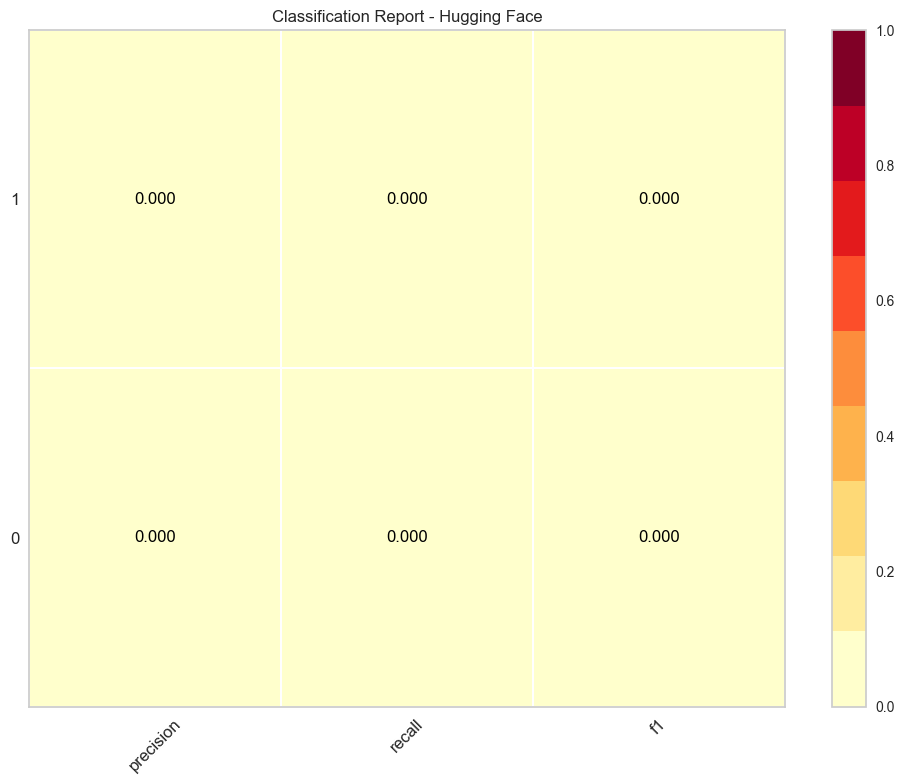

In [9]:
import importlib
import importlib.util
from pathlib import Path

import deckard.plugins.yellowbrick.plot as yellowbrick_plot_module

yellowbrick_plot_module = importlib.reload(yellowbrick_plot_module)
YellowbrickPlotConfig = yellowbrick_plot_module.YellowbrickPlotConfig
classifier_viz_types = yellowbrick_plot_module.classifier_viz_types

artifact_dir = Path.cwd().resolve() / "build" / "huggingface"
artifact_dir.mkdir(parents=True, exist_ok=True)
plot_dir = artifact_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

available_plot_types = list(classifier_viz_types)
yellowbrick_primary_path = (plot_dir / "huggingface_classification_report.png").as_posix()

yellowbrick_env = {
    "yellowbrick_installed": importlib.util.find_spec("yellowbrick") is not None,
    "plot_mode": "classifier_only",
    "available_plot_types": available_plot_types,
    "primary_plot_file": yellowbrick_primary_path,
}

primary_plot_result = {
    "attempted": False,
    "succeeded": False,
    "error": None,
}
if "experiment_cfg" in globals() and experiment_cfg is not None:
    primary_plot_result["attempted"] = True
    try:
        yellowbrick_primary = YellowbrickPlotConfig(
            experiment=experiment_cfg,
            plot_type="classification_report",
            features="all",
            classes="all",
            title="Classification Report - Hugging Face",
            save_path=yellowbrick_primary_path,
        )
        yellowbrick_primary()
        primary_plot_result["succeeded"] = Path(yellowbrick_primary_path).exists()
    except Exception as exc:
        primary_plot_result["error"] = str(exc)

{"yellowbrick_env": yellowbrick_env, "primary_plot_result": primary_plot_result}

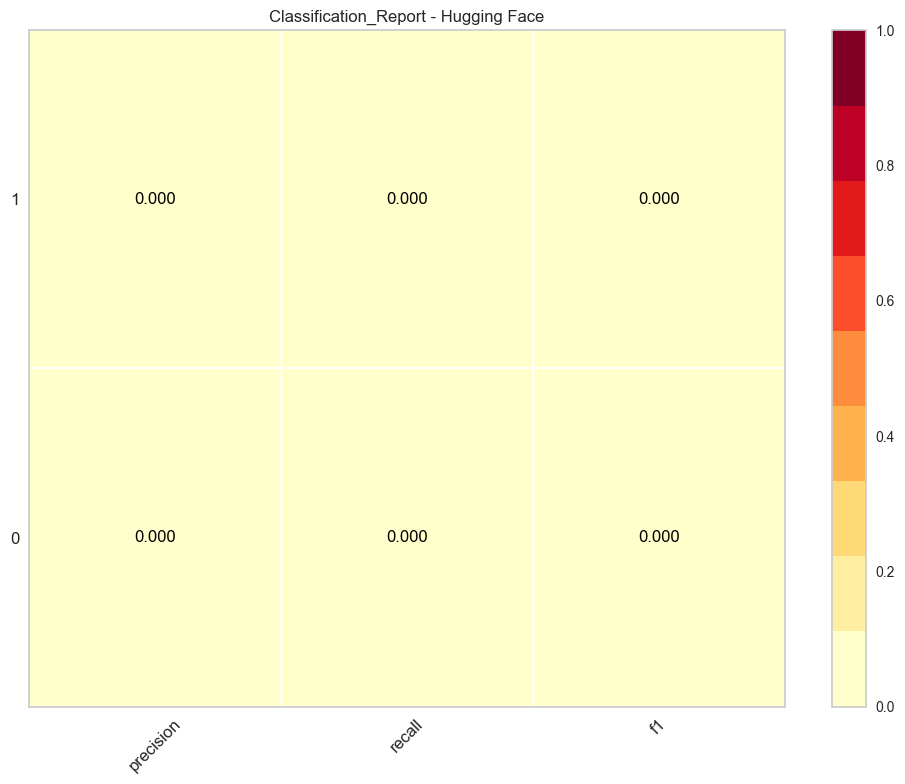

In [10]:
import matplotlib.pyplot as plt

plots = []
status = []
errors = []

for plot_type in available_plot_types:
    plots.append(plot_type)
    if "experiment_cfg" not in globals() or experiment_cfg is None:
        status.append("Not Implemented")
        errors.append("No experiment config available")
        continue

    try:
        attempt = YellowbrickPlotConfig(
            experiment=experiment_cfg,
            plot_type=plot_type,
            features="all",
            classes="all",
            title=f"{plot_type.title()} - Hugging Face",
        )
        attempt()
        status.append("Implemented")
        errors.append("")
    except Exception as exc:
        plt.close()
        status.append("Not Implemented")
        errors.append(str(exc))

In [11]:
import pandas as pd

yellowbrick_status_df = pd.DataFrame(
    {
        "Plot Type": plots,
        "Status": status,
        "Error": errors,
    }
)

yellowbrick_status_df

,Plot Type,Status,Error
0,roc_auc,Not Implemented,y_true takes value in {2} and pos_label is not...
1,precision_recall_curve,Not Implemented,y_true takes value in {2} and pos_label is not...
2,classification_report,Implemented,
3,class_prediction_error,Not Implemented,"The number of FixedLocator locations (3), usua..."
4,discrimination_threshold,Not Implemented,'PretrainedSequenceClassificationTransformer' ...


## 10. Seaborn Plotter

This follows the PyTorch notebook pattern: build a compact in-memory results table, then render scatter and line plots through `SeabornPlotConfigList`.

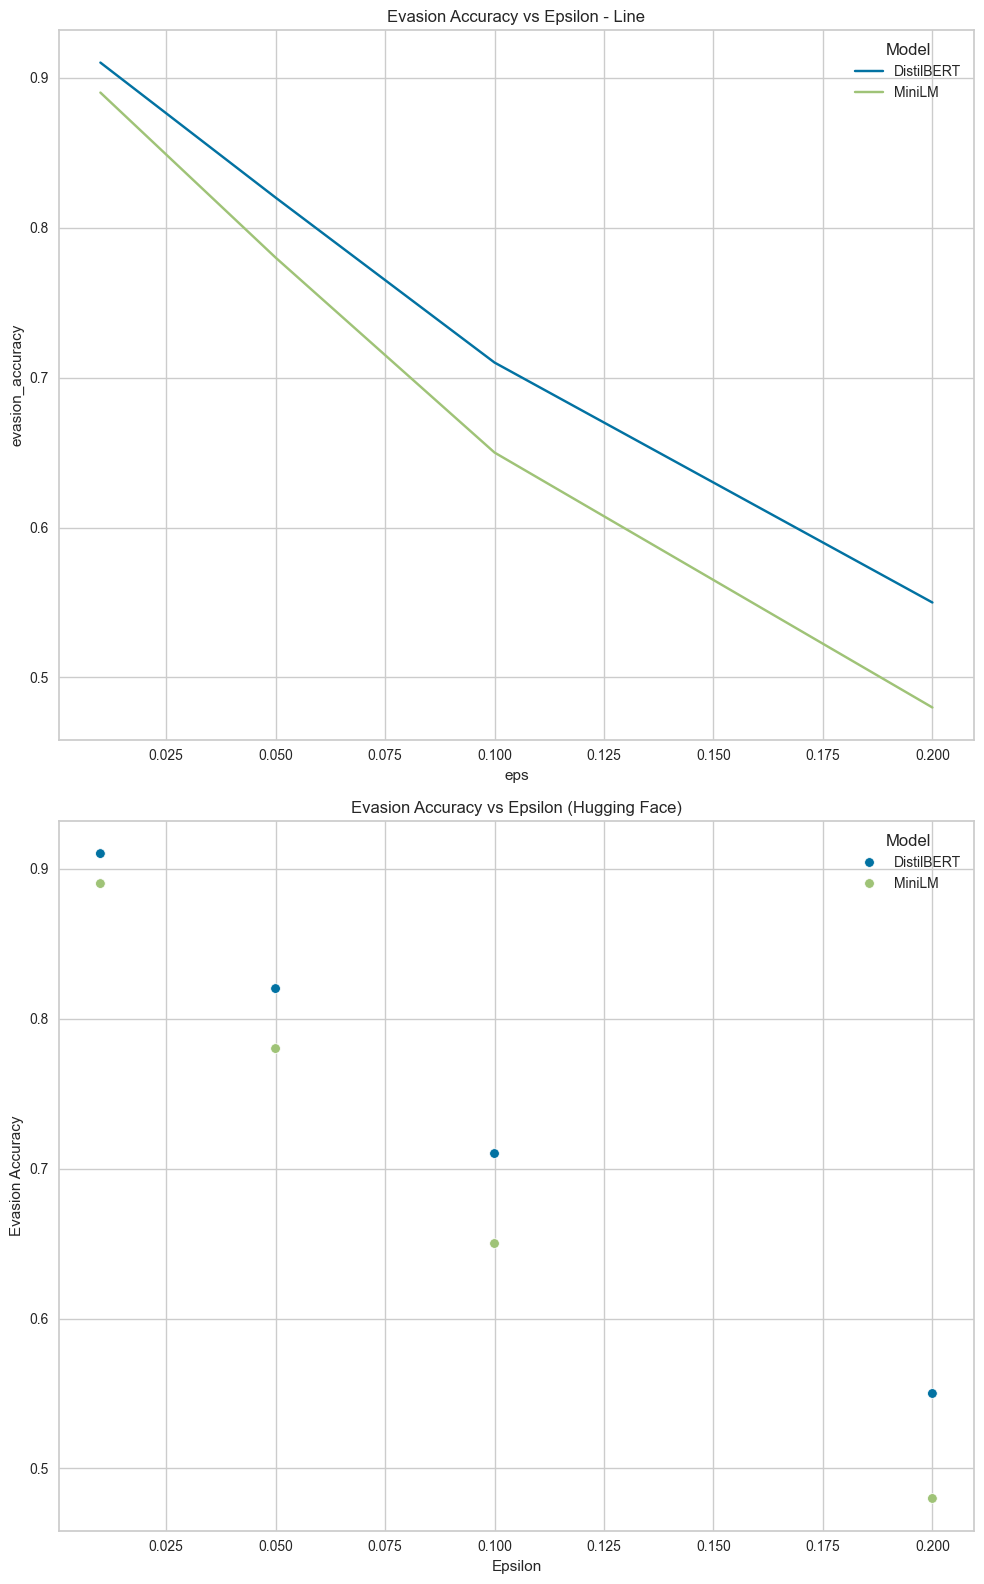

Seaborn plots written: /Users/c.meyers/Documents/deckard/docs/notebooks/build/huggingface/plots/huggingface_scatter.png /Users/c.meyers/Documents/deckard/docs/notebooks/build/huggingface/plots/huggingface_line.png


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from deckard.plot import SeabornPlotConfig, SeabornPlotConfigList

results_df = pd.DataFrame(
    {
        "eps": [0.01, 0.05, 0.10, 0.20, 0.01, 0.05, 0.10, 0.20],
        "evasion_accuracy": [0.91, 0.82, 0.71, 0.55, 0.89, 0.78, 0.65, 0.48],
        "accuracy": [0.94, 0.94, 0.94, 0.94, 0.91, 0.91, 0.91, 0.91],
        "model": ["DistilBERT"] * 4 + ["MiniLM"] * 4,
    }
)

artifact_dir = Path.cwd().resolve() / "build" / "huggingface"
artifact_dir.mkdir(parents=True, exist_ok=True)
plot_dir = artifact_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

results_csv = artifact_dir / "huggingface_results.csv"
results_df.to_csv(results_csv, index=False)

scatter_path = (plot_dir / "huggingface_scatter.png").as_posix()
line_path = (plot_dir / "huggingface_line.png").as_posix()

seaborn_scatter = SeabornPlotConfig(
    plot_type="scatter",
    data_file=results_csv.as_posix(),
    x="eps",
    y="evasion_accuracy",
    hue="model",
    title="Evasion Accuracy vs Epsilon (Hugging Face)",
    xlabel="Epsilon",
    ylabel="Evasion Accuracy",
    legend_title="Model",
    plot_file=scatter_path,
)

plot_list = SeabornPlotConfigList(
    data_file=results_csv.as_posix(),
    plots=[
        SeabornPlotConfig(
            plot_type="line",
            data_file=results_csv.as_posix(),
            x="eps",
            y="evasion_accuracy",
            hue="model",
            title="Evasion Accuracy vs Epsilon - Line",
            plot_file=line_path,
            legend_title="Model",
        ),
        seaborn_scatter,
    ],
)

_ = plot_list()
plt.show()
print("Seaborn plots written:", scatter_path, line_path)